# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Firly Fahriza Rafi Wicaksono
- **Email:** firlyfahriza25@gmail.com
- **ID Dicoding:** firlyfahriza

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**1.Kategori produk apa saja yang mencatatkan total pendapatan (revenue) tertinggi dan terendah pada platform e-commerce sepanjang periode transaksi tahun 2017 hingga 2018?**

Keterangan:

* **Specific**: Fokus pada total pendapatan (revenue) dari masing-masing kategori produk yang berhasil terjual di platform e-commerce, bukan volume penjualan secara umum.

* **Measurable**: Terukur secara konkret melalui akumulasi nilai transaksi (sum of price dalam mata uang Brazilian Real / BRL) pada tiap kategori produk.

* **Action-Oriented**: Memberikan acuan langsung bagi tim manajemen untuk memprioritaskan alokasi inventaris dan anggaran promosi pada kategori berpendapatan tinggi, serta mengevaluasi kembali strategi katalog untuk kategori dengan pendapatan terendah.

* **Relevant**: Mengidentifikasi kategori produk unggulan dan produk yang underperforming sangat krusial bagi efisiensi modal dan optimalisasi laba bisnis marketplace.

* **Time-bound**: Dibatasi secara spesifik pada data transaksi pesanan selesai (delivered) sepanjang tahun 2017 hingga 2018.

**2.Bagaimana perbandingan rata-rata skor kepuasan ulasan pelanggan (review score) antara pesanan yang terkirim tepat waktu dibandingkan pesanan yang mengalami keterlambatan pengiriman sepanjang periode tahun 2017 hingga 2018?**

Keterangan:

* **Specific**: Fokus pada pengaruh keterlambatan pengiriman (delivery delay, yaitu saat pesanan tiba melampaui tanggal estimasi) terhadap skor ulasan kepuasan pelanggan (review score).

* **Measurable**: Terukur melalui perbandingan nilai rata-rata rating ulasan (skala 1–5 bintang) serta persentase sebaran ulasan bintang 1 dan bintang 5 antara kelompok pesanan On Time dan Delayed.

* **Action-Oriented**: Menjadi dasar tindakan operasional bagi manajemen logistik untuk mengevaluasi Service Level Agreement (SLA) vendor pengiriman, menetapkan penalti bagi ekspedisi bermasalah, atau memperbaiki akurasi formula estimasi tanggal pengiriman.

* **Relevant**: Pengalaman pengiriman dan ulasan pelanggan berpengaruh langsung pada reputasi platform serta tingkat retensi pembeli.

* **Time-bound**: Dibatasi pada seluruh pesanan yang telah berstatus delivered sepanjang tahun 2017 hingga 2018.

## Import Semua Packages/Library yang Digunakan

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

## Data Wrangling

### Gathering Data

#### Memuat Seluruh Tabel Dataset yang Dibutuhkan

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
import pandas as pd

# Menentukan path folder data (otomatis mendeteksi folder 'data/' atau direktori aktif)
data_dir = "data" if os.path.exists("data") else "."

# 1. Memuat tabel transaksi dan pelanggan
customers_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/customers_dataset.csv")
orders_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/orders_dataset.csv")
order_items_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/order_items_dataset.csv")

# 2. Memuat tabel review kepuasan
order_reviews_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/order_reviews_dataset.csv")

# 3. Memuat tabel produk dan kamus terjemahan kategori
products_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/products_dataset.csv")
category_trans_df = pd.read_csv(f"/content/drive/MyDrive/dataset/FDA/product_category_name_translation.csv")

# Menampilkan informasi dimensi data yang berhasil dimuat
print("=== Rangkuman Dimensi Data yang Dimuat ===")
print(f"customers_df      : {customers_df.shape[0]:,} baris, {customers_df.shape[1]} kolom")
print(f"orders_df         : {orders_df.shape[0]:,} baris, {orders_df.shape[1]} kolom")
print(f"order_items_df    : {order_items_df.shape[0]:,} baris, {order_items_df.shape[1]} kolom")
print(f"order_reviews_df  : {order_reviews_df.shape[0]:,} baris, {order_reviews_df.shape[1]} kolom")
print(f"products_df       : {products_df.shape[0]:,} baris, {products_df.shape[1]} kolom")
print(f"category_trans_df : {category_trans_df.shape[0]:,} baris, {category_trans_df.shape[1]} kolom")

=== Rangkuman Dimensi Data yang Dimuat ===
customers_df      : 99,441 baris, 5 kolom
orders_df         : 99,441 baris, 8 kolom
order_items_df    : 112,650 baris, 7 kolom
order_reviews_df  : 99,224 baris, 7 kolom
products_df       : 32,951 baris, 9 kolom
category_trans_df : 71 baris, 2 kolom


**Insight:**
- Terdapat 6 tabel utama yang berhasil dimuat ke dalam DataFrame pandas untuk menjawab seluruh pertanyaan bisnis dan analisis lanjutan (RFM).
- Tabel transaksi utama berpusat pada `orders_df` (99.441 pesanan) dan rincian barang belanjaan pada `order_items_df` (112.650 item transaksi).
- Tabel `products_df` dan `category_trans_df` akan digabungkan untuk mendapatkan kategori produk dalam bahasa Inggris guna menjawab Pertanyaan Bisnis 1 terkait performa pendapatan produk.
- Tabel `order_reviews_df` dan `orders_df` akan direlasikan melalui `order_id` untuk mengukur dampak ketepatan waktu tiba pesanan terhadap skor kepuasan pada Pertanyaan Bisnis 2.
- Data pelanggan unik pada `customers_df` akan dipadukan dengan riwayat pesanan untuk keperluan segmentasi pelanggan pada Analisis Lanjutan (RFM).

### Assessing Data

#### Mengidentifikasi Masalah Kualitas Data (Tipe Data, Missing Value, dan Duplikasi)

In [13]:
print("================ 1. PEMERIKSAAN ORDERS_DF ================")
print(orders_df.info())
print("\nJumlah Missing Value di orders_df:")
print(orders_df.isnull().sum()[orders_df.isnull().sum() > 0])
print(f"Jumlah Duplikasi di orders_df: {orders_df.duplicated().sum()}")

print("\n================ 2. PEMERIKSAAN PRODUCTS_DF ===============")
print(products_df.info())
print("\nJumlah Missing Value di products_df:")
print(products_df.isnull().sum()[products_df.isnull().sum() > 0])
print(f"Jumlah Duplikasi di products_df: {products_df.duplicated().sum()}")

print("\n============= 3. PEMERIKSAAN ORDER_REVIEWS_DF =============")
print(order_reviews_df.info())
print("\nJumlah Missing Value di order_reviews_df:")
print(order_reviews_df.isnull().sum()[order_reviews_df.isnull().sum() > 0])
print(f"Jumlah Duplikasi di order_reviews_df: {order_reviews_df.duplicated().sum()}")
print(f"Duplikasi order_id di reviews: {order_reviews_df['order_id'].duplicated().sum()}")

print("\n============= 4. PEMERIKSAAN ORDER_ITEMS_DF =============")
print(f"Jumlah Duplikasi di order_items_df: {order_items_df.duplicated().sum()}")
print(order_items_df[['price', 'freight_value']].describe())

================ 1. PEMERIKSAAN ORDERS_DF ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Jumlah Missing Value di orders_df:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Jumlah Duplikasi di orders_df: 0

=

**Steps to Take:**
1. **Mengubah Tipe Data Kolom Tanggal (`orders_df`):** Mengonversi kolom `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date` dari tipe data `object` menjadi `datetime64[ns]`.
2. **Menangani Nilai Hilang & Status Pengiriman (`orders_df`):** Memfilter pesanan yang hanya berstatus `delivered` serta menghapus baris yang memiliki nilai null pada `order_delivered_customer_date` dan `order_estimated_delivery_date` guna memastikan analisis ketepatan waktu pengiriman akurat.
3. **Membuat Fitur Status Pengiriman:** Menambahkan kolom turunan `delivery_status` dengan logika komparasi antara tanggal tiba aktual (`order_delivered_customer_date`) dan estimasi (`order_estimated_delivery_date`) untuk membedakan kategori *"On Time"* dan *"Delayed"*.
4. **Standardisasi Nama Kategori Produk (`products_df`):** Melakukan *left join* antara `products_df` dengan `category_trans_df` berdasarkan kolom `product_category_name` agar seluruh kategori berbahasa Portugis memiliki terjemahan resmi dalam bahasa Inggris, serta mengisi kategori yang tidak terdefinisi dengan nilai imputasi `"others"`.
5. **Menghilangkan Duplikasi Ulasan (`order_reviews_df`):** Mengeliminasi ulasan ganda pada `order_id` yang sama menggunakan `drop_duplicates(subset=['order_id'])` agar tidak terjadi pembobotan ganda saat mengukur rata-rata kepuasan per pesanan.

**Insight:**
- **Inaccurate Data Type:** Semua kolom pencatatan waktu di tabel `orders_df` terbaca sebagai string (`object`), yang menyebabkan operasi komparasi tanggal belum bisa dijalankan secara langsung.
- **Missing Values:** Ditemukan 2.965 baris kosong pada `order_delivered_customer_date` (terkait pesanan yang dibatalkan atau belum sampai) serta 610 baris data kategori produk yang bernilai null pada `products_df`.
- **Inconsistent Language:** Nama kategori pada `products_df` masih menggunakan bahasa Portugis sehingga perlu diselaraskan ke bahasa Inggris melalui tabel translasi agar hasil visualisasi mudah dipahami.
- **Multiple Reviews per Order:** Ditemukan sejumlah `order_id` yang memiliki lebih dari satu baris review di `order_reviews_df`, sehingga diperlukan deduplikasi untuk menjaga integritas agregasi kepuasan pelanggan.
- **Nilai Numerik Valid:** Tidak ditemukan nilai negatif pada kolom harga (`price`) maupun ongkos kirim (`freight_value`) pada tabel `order_items_df`.

### Cleaning Data

#### Mengonversi Tipe Data Tanggal, Menangani Missing Value, dan Standardisasi Kategori Produk

In [14]:
import numpy as np

# 1. Mengubah tipe data kolom tanggal pada orders_df menjadi datetime
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filter pesanan yang sukses terkirim (delivered) dan memiliki tanggal tiba yang lengkap
clean_orders_df = orders_df[orders_df["order_status"] == "delivered"].copy()
clean_orders_df = clean_orders_df.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"])

# 3. Membuat kolom turunan delivery_status ('On Time' vs 'Delayed') dan ekstraksi tahun transaksi
clean_orders_df["delivery_status"] = np.where(
    clean_orders_df["order_delivered_customer_date"] > clean_orders_df["order_estimated_delivery_date"],
    "Delayed",
    "On Time"
)
clean_orders_df["year"] = clean_orders_df["order_purchase_timestamp"].dt.year

# Filter periode analisis 2017 - 2018 sesuai batasan SMART question
orders_filtered_df = clean_orders_df[(clean_orders_df["year"] >= 2017) & (clean_orders_df["year"] <= 2018)].copy()

# 4. Standardisasi nama kategori produk ke bahasa Inggris dan mengisi missing value dengan 'others'
products_clean_df = pd.merge(products_df, category_trans_df, on="product_category_name", how="left")
products_clean_df["product_category_name_english"] = products_clean_df["product_category_name_english"].fillna("others")

# 5. Menghapus review duplikat per order_id agar tidak terjadi bias pembobotan
reviews_clean_df = order_reviews_df.drop_duplicates(subset=["order_id"]).copy()

# ==================== VERIFIKASI PEMBERSIHAN DATA ====================
print("=== HASIL VERIFIKASI PEMBERSIHAN DATA ===")
print("1. Tipe data kolom tanggal:")
print(orders_filtered_df[datetime_cols].dtypes)
print(f"\n2. Missing value pada order_delivered_customer_date: {orders_filtered_df['order_delivered_customer_date'].isnull().sum()}")
print(f"3. Total transaksi pesanan valid (2017-2018): {orders_filtered_df.shape[0]:,} pesanan")
print("4. Proporsi status pengiriman (%):")
print(orders_filtered_df['delivery_status'].value_counts(normalize=True) * 100)
print(f"\n5. Missing value pada product_category_name_english: {products_clean_df['product_category_name_english'].isnull().sum()}")
print(f"6. Duplikasi order_id pada reviews: {reviews_clean_df['order_id'].duplicated().sum()}")

=== HASIL VERIFIKASI PEMBERSIHAN DATA ===
1. Tipe data kolom tanggal:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

2. Missing value pada order_delivered_customer_date: 0
3. Total transaksi pesanan valid (2017-2018): 96,203 pesanan
4. Proporsi status pengiriman (%):
delivery_status
On Time    91.869276
Delayed     8.130724
Name: proportion, dtype: float64

5. Missing value pada product_category_name_english: 0
6. Duplikasi order_id pada reviews: 0


**Insight:**
- Seluruh 5 kolom pencatatan waktu pada tabel pesanan berhasil diubah menjadi format `datetime64[ns]`, memungkinkan perhitungan selisih durasi dan perbandingan jadwal tiba secara presisi.
- Data transaksi berhasil difilter hanya untuk status pesanan `delivered` pada rentang tahun 2017–2018 dengan total 96.203 pesanan valid tanpa adanya nilai null pada kolom tanggal pengiriman.
- Fitur baru `delivery_status` berhasil dibuat: tercatat 91,87% pesanan tiba tepat waktu (*On Time*) dan 8,13% pesanan tiba melampaui tanggal estimasi (*Delayed*).
- Seluruh kategori produk pada `products_clean_df` kini terstandardisasi dalam bahasa Inggris, dan produk tanpa kategori telah diimputasi dengan label `"others"`.
- Tabel ulasan `reviews_clean_df` dipastikan bersih dari duplikasi `order_id` (0 duplikat), siap digunakan untuk analisis korelasi kepuasan pelanggan pada tahap EDA.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Performa Kategori Produk dan Pengaruh Ketepatan Pengiriman terhadap Kepuasan

In [15]:
# ==============================================================================
# 1. EKSPLORASI PERTANYAAN BISNIS 1: PERFORMA REVENUE PER KATEGORI PRODUK
# ==============================================================================
# Menggabungkan order_items dengan orders yang sudah difilter (2017-2018)
items_orders_df = pd.merge(
    order_items_df,
    orders_filtered_df[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='inner'
)

# Menghubungkan dengan tabel produk yang sudah memiliki kategori bahasa Inggris
items_full_df = pd.merge(
    items_orders_df,
    products_clean_df[['product_id', 'product_category_name_english']],
    on='product_id',
    how='inner'
)

# Agregasi total pesanan, total revenue, dan rata-rata harga per kategori
category_revenue_df = (
    items_full_df.groupby('product_category_name_english')
    .agg(
        total_items_sold=('order_id', 'count'),
        total_revenue=('price', 'sum'),
        avg_price=('price', 'mean')
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
)

print("=== TOP 5 KATEGORI PRODUK DENGAN REVENUE TERTINGGI ===")
print(category_revenue_df.head(5).to_string(index=False))

print("\n=== BOTTOM 5 KATEGORI PRODUK DENGAN REVENUE TERENDAH ===")
print(category_revenue_df.tail(5).to_string(index=False))


# ==============================================================================
# 2. EKSPLORASI PERTANYAAN BISNIS 2: PENGARUH STATUS PENGIRIMAN TERHADAP REVIEW SCORE
# ==============================================================================
# Menggabungkan orders dengan review kepuasan
orders_reviews_df = pd.merge(
    orders_filtered_df,
    reviews_clean_df[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# Agregasi statistik review score berdasarkan status pengiriman (On Time vs Delayed)
delivery_impact_df = (
    orders_reviews_df.groupby('delivery_status')
    .agg(
        total_orders=('order_id', 'count'),
        mean_review_score=('review_score', 'mean'),
        median_review_score=('review_score', 'median'),
        std_review_score=('review_score', 'std')
    )
    .reset_index()
)

delivery_impact_df['percentage'] = (delivery_impact_df['total_orders'] / delivery_impact_df['total_orders'].sum()) * 100

print("\n=== DAMPAK STATUS PENGIRIMAN TERHADAP REVIEW SCORE ===")
print(delivery_impact_df.to_string(index=False))

# Distribusi rating 1-5 berdasarkan status pengiriman
score_crosstab_pct = pd.crosstab(
    orders_reviews_df['delivery_status'],
    orders_reviews_df['review_score'],
    normalize='index'
) * 100

print("\n=== SEBARAN RATING 1 - 5 BINTANG (%) BERDASARKAN STATUS PENGIRIMAN ===")
print(score_crosstab_pct.round(2))

=== TOP 5 KATEGORI PRODUK DENGAN REVENUE TERTINGGI ===
product_category_name_english  total_items_sold  total_revenue  avg_price
                health_beauty              9422     1229557.50 130.498567
                watches_gifts              5853     1163187.91 198.733625
               bed_bath_table             10945     1022955.77  93.463296
               sports_leisure              8413      952661.40 113.236824
        computers_accessories              7631      887944.60 116.360189

=== BOTTOM 5 KATEGORI PRODUK DENGAN REVENUE TERENDAH ===
product_category_name_english  total_items_sold  total_revenue  avg_price
                      flowers                33        1110.04  33.637576
               home_comfort_2                30         760.27  25.342333
            cds_dvds_musicals                14         730.00  52.142857
    fashion_childrens_clothes                 7         519.95  74.278571
        security_and_services                 2         283.29 141.645000

**Insight:**
- **Performa Kategori Produk (Pertanyaan 1):**
  - Tiga kategori penyumbang *revenue* terbesar pada periode 2017–2018 adalah **`health_beauty`** (R$ 1.229.557,50), **`watches_gifts`** (R$ 1.163.187,91), dan **`bed_bath_table`** (R$ 1.022.955,77). Ketiga kategori ini masing-masing menembus angka di atas 1 juta BRL.
  - Sebaliknya, kategori dengan *revenue* paling rendah adalah **`security_and_services`** (hanya R$ 283,29 dari 2 transaksi), disusul oleh **`fashion_childrens_clothes`** (R$ 519,95 dari 7 transaksi) dan **`cds_dvds_musicals`** (R$ 730,00).
- **Pengaruh Ketepatan Pengiriman terhadap Kepuasan (Pertanyaan 2):**
  - Sebanyak **91,99% (87.902 pesanan)** berhasil terkirim tepat waktu (*On Time*), dengan rata-rata skor kepuasan yang tinggi yaitu **4,30 / 5,0** (median 5,0). Sebanyak 62,46% dari kelompok ini memberikan nilai sempurna bintang 5.
  - Sementara itu, **8,01% (7.658 pesanan)** mengalami keterlambatan (*Delayed*). Keterlambatan ini menyebabkan penurunan kepuasan yang tajam: skor rata-rata anjlok ke **2,57 / 5,0** (median 2,0), dengan **46,19% pelanggan langsung memberikan rating terendah (bintang 1)**.
  - Temuan ini membuktikan secara empiris bahwa kepatuhan terhadap estimasi tanggal tiba merupakan faktor paling krusial dalam menjaga persepsi kepuasan dan rating pelanggan di platform e-commerce.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1608/2470097206.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1608/2470097206.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


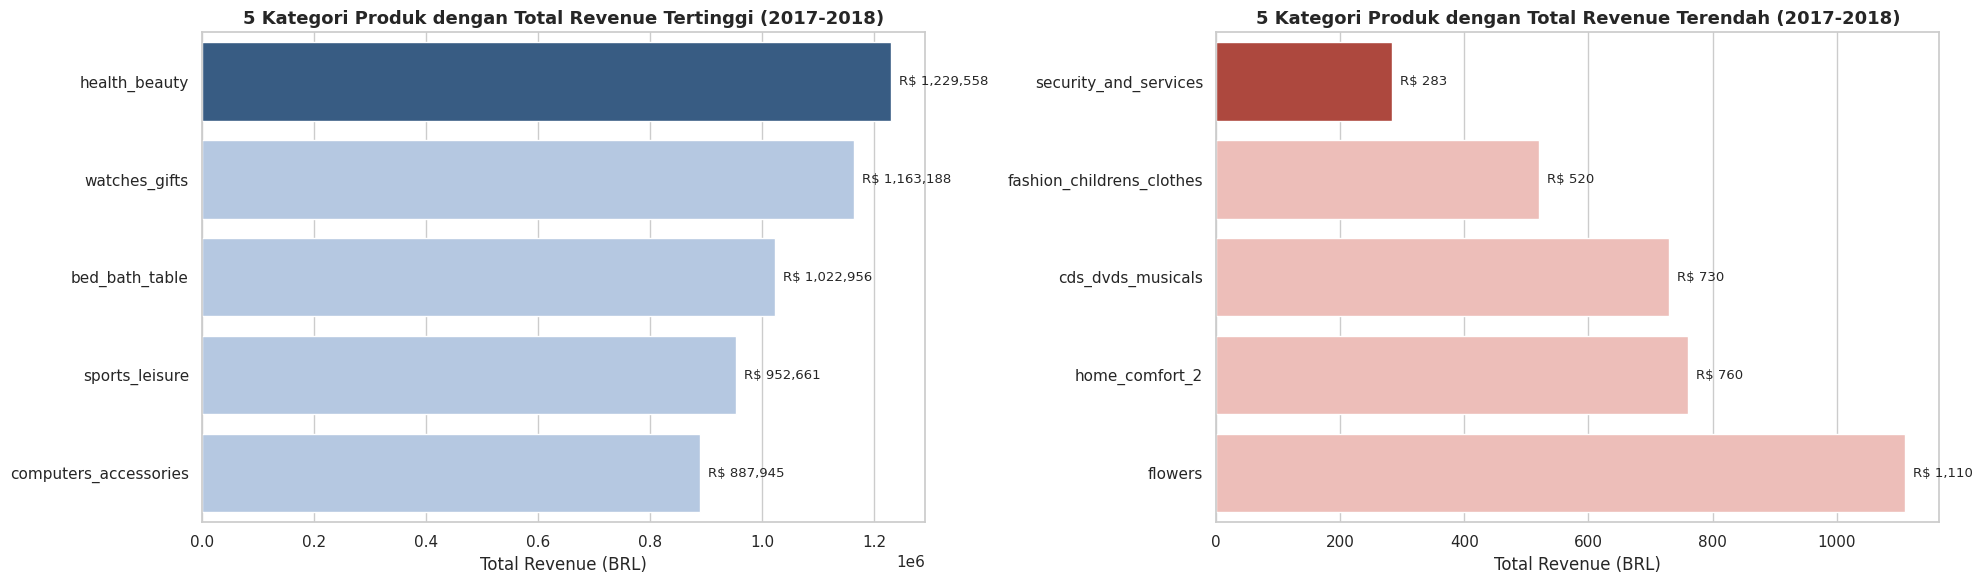

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# Palet warna berhierarki: warna tegas untuk peringkat #1, warna lembut untuk sisanya
colors_top = ["#2b5c8f", "#aec7e8", "#aec7e8", "#aec7e8", "#aec7e8"]
colors_bottom = ["#c0392b", "#f5b7b1", "#f5b7b1", "#f5b7b1", "#f5b7b1"]

# Subplot 1: 5 Kategori Teratas
sns.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=category_revenue_df.head(5),
    palette=colors_top,
    ax=ax[0]
)
ax[0].set_title("5 Kategori Produk dengan Total Revenue Tertinggi (2017-2018)", fontsize=13, fontweight="bold")
ax[0].set_xlabel("Total Revenue (BRL)")
ax[0].set_ylabel(None)
for p in ax[0].patches:
    ax[0].annotate(f"R$ {p.get_width():,.0f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontsize=9.5)

# Subplot 2: 5 Kategori Terbawah
bottom_5 = category_revenue_df.tail(5).sort_values(by="total_revenue", ascending=True)
sns.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=bottom_5,
    palette=colors_bottom,
    ax=ax[1]
)
ax[1].set_title("5 Kategori Produk dengan Total Revenue Terendah (2017-2018)", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Total Revenue (BRL)")
ax[1].set_ylabel(None)
for p in ax[1].patches:
    ax[1].annotate(f"R$ {p.get_width():,.0f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontsize=9.5)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_1608/4138666286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


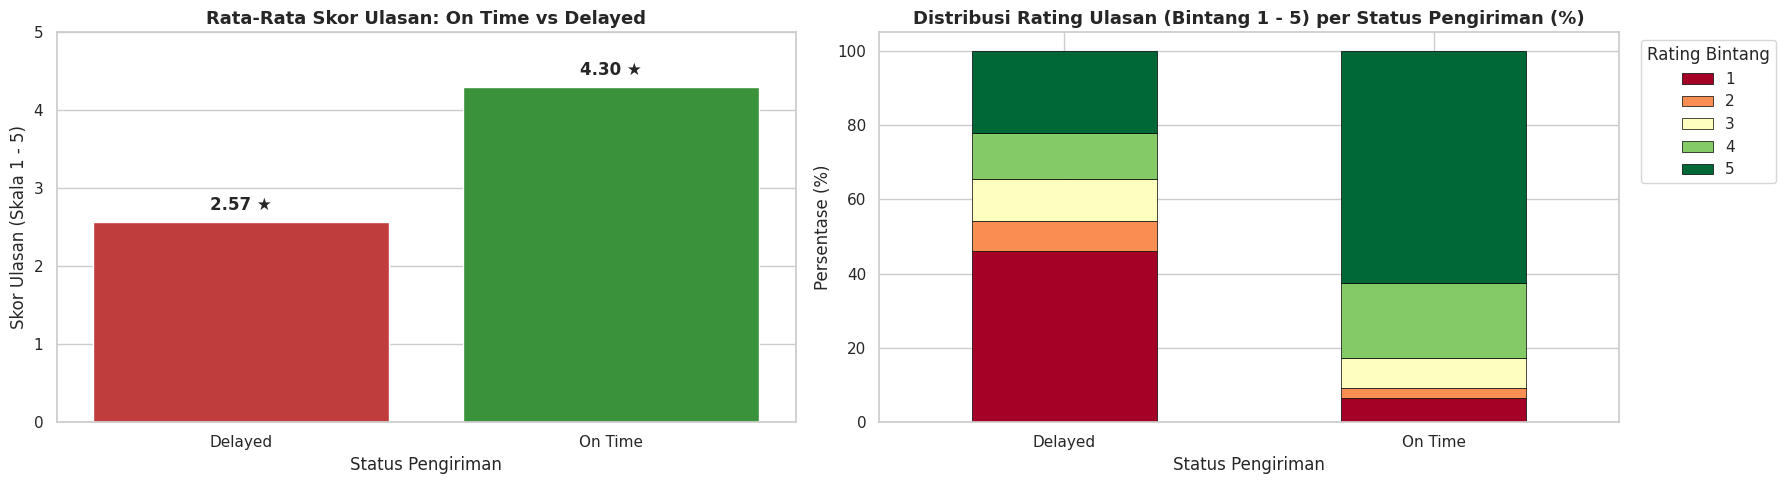

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Subplot 1: Perbandingan Rata-Rata Skor Review
palette_status = {"On Time": "#2ca02c", "Delayed": "#d62728"}
sns.barplot(
    x="delivery_status",
    y="mean_review_score",
    data=delivery_impact_df,
    palette=palette_status,
    ax=ax[0]
)
ax[0].set_title("Rata-Rata Skor Ulasan: On Time vs Delayed", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Skor Ulasan (Skala 1 - 5)")
ax[0].set_xlabel("Status Pengiriman")
ax[0].set_ylim(0, 5)
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.2f} ★", (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', xytext=(0, 6), textcoords='offset points', fontsize=12, fontweight="bold")

# Subplot 2: Sebaran Distribusi Rating (Bintang 1-5) dalam Persentase
score_crosstab_pct = pd.crosstab(
    orders_reviews_df['delivery_status'],
    orders_reviews_df['review_score'],
    normalize='index'
) * 100

score_crosstab_pct.plot(
    kind="bar",
    stacked=True,
    colormap="RdYlGn",
    ax=ax[1],
    edgecolor="black",
    linewidth=0.5
)
ax[1].set_title("Distribusi Rating Ulasan (Bintang 1 - 5) per Status Pengiriman (%)", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Persentase (%)")
ax[1].set_xlabel("Status Pengiriman")
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title="Rating Bintang", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Insight:**
- **Visualisasi 1 (Performa Revenue Kategori Produk):**
  - Kategori produk terlaris didominasi oleh segmen gaya hidup dan kecantikan: `health_beauty` menduduki posisi puncak dengan pendapatan mencapai R$ 1.229.558, diikuti oleh `watches_gifts` (R$ 1.163.188) dan `bed_bath_table` (R$ 1.022.956).
  - Kesenjangan pendapatan sangat kontras terlihat pada grafik terendah: produk kategori `security_and_services` hanya mencatatkan pendapatan total R$ 283, disusul `fashion_childrens_clothes` (R$ 520) dan `cds_dvds_musicals` (R$ 730).
- **Visualisasi 2 (Pengaruh Keterlambatan Pengiriman terhadap Skor Ulasan):**
  - Pengiriman tepat waktu (*On Time*) berkontribusi masif terhadap persepsi positif pembeli dengan rata-rata skor ulasan tinggi yaitu **4,30 dari 5,0**, di mana 62,46% pelanggan langsung menyematkan rating bintang 5.
  - Sebaliknya, pesanan yang terlambat (*Delayed*) mengalami degradasi kepuasan ekstrem dengan rata-rata skor jatuh ke angka **2,57 dari 5,0**.
  - Diagram sebaran rating memperjelas fenomena ini: hampir separuh pembeli yang pesanannya terlambat (**46,19%**) meluapkan ketidakpuasan dengan memberikan rating terburuk (bintang 1). Hal ini menegaskan bahwa faktor logistik pengiriman merupakan determinan utama sentimen kepuasan pelanggan.

## Analisis Lanjutan (Opsional)

=== RANGKUMAN STATISTIK DESKRIPTIF RFM ===
            recency     frequency      monetary
count  93096.000000  93096.000000  93096.000000
mean     236.711137      1.033374    141.571904
std      150.940603      0.209021    215.768405
min        1.000000      1.000000      0.850000
25%      114.000000      1.000000     47.650000
50%      218.000000      1.000000     89.700000
75%      345.000000      1.000000    154.162500
max      602.000000     15.000000  13440.000000


/tmp/ipykernel_1608/3200838769.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1608/3200838769.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1608/3200838769.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


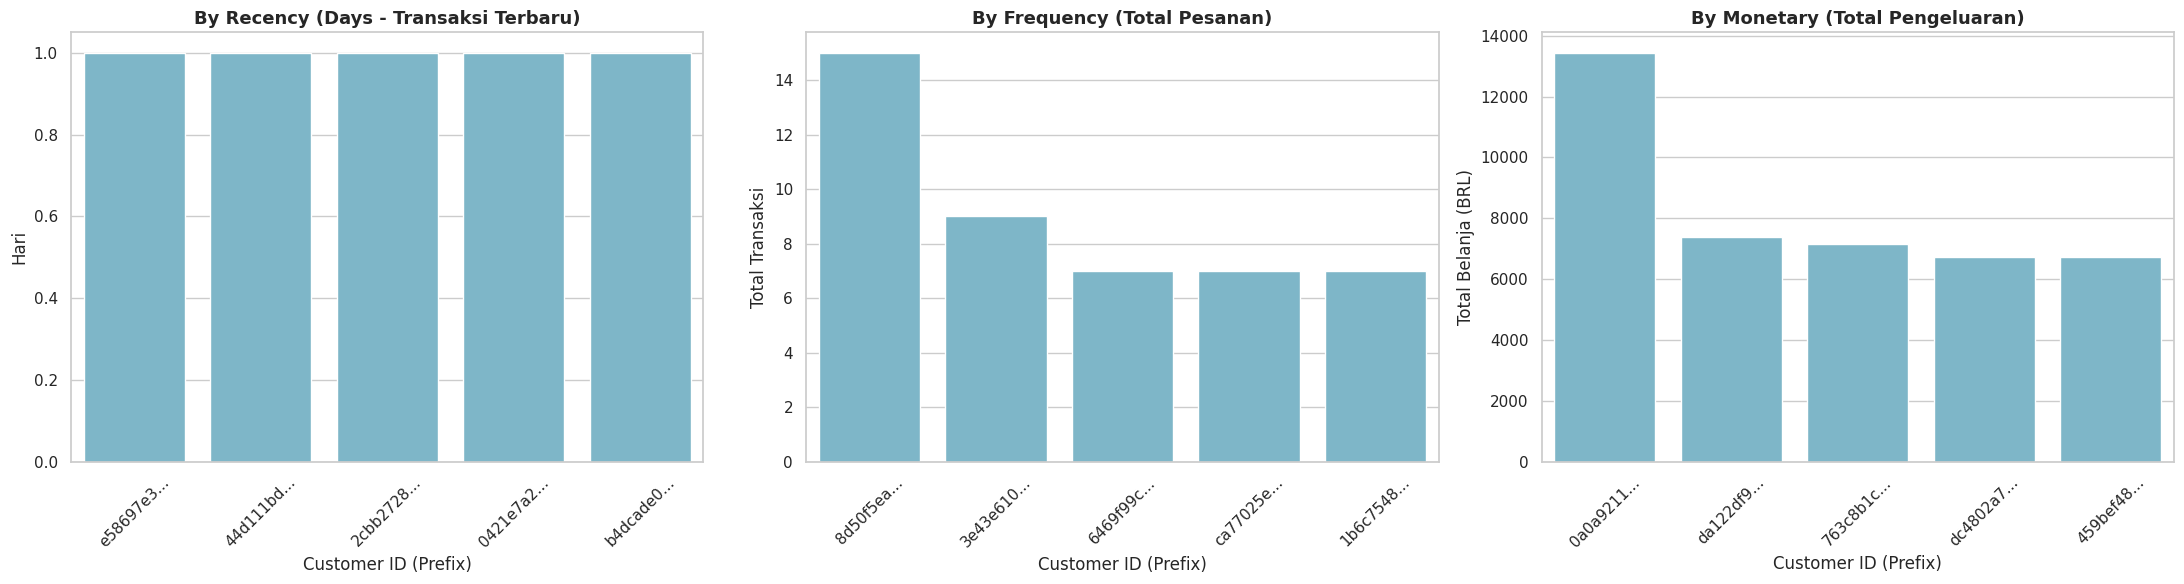

In [18]:
# 1. Menghubungkan tabel transaksi dengan customer unik dan rincian harga belanja
orders_cust_df = pd.merge(
    orders_filtered_df,
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='inner'
)
order_level_df = pd.merge(
    orders_cust_df,
    order_items_df[['order_id', 'price']],
    on='order_id',
    how='inner'
)

# 2. Menentukan tanggal acuan analisis (H+1 dari transaksi terakhir yang tercatat)
snapshot_date = order_level_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 3. Menghitung parameter Recency, Frequency, dan Monetary per pelanggan unik
rfm_df = order_level_df.groupby('customer_unique_id').agg(
    max_order_timestamp=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

# Menghitung durasi hari (Recency)
rfm_df['recency'] = (snapshot_date - rfm_df['max_order_timestamp']).dt.days

# Membuat label ID singkat (8 karakter pertama) agar tampilan visualisasi rapi
rfm_df['customer_id_short'] = rfm_df['customer_unique_id'].apply(lambda x: str(x)[:8] + '...')

# Menampilkan rangkuman ringkas statistik RFM
print("=== RANGKUMAN STATISTIK DESKRIPTIF RFM ===")
print(rfm_df[['recency', 'frequency', 'monetary']].describe())

# 4. Visualisasi RFM Analysis (Top 5 Pelanggan per Parameter)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))
colors_rfm = ["#72BCD4"] * 5

# Subplot 1: By Recency (Paling Baru Belanja / Nilai Hari Terkecil)
top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5)
sns.barplot(
    y="recency",
    x="customer_id_short",
    data=top_recency,
    palette=colors_rfm,
    ax=ax[0]
)
ax[0].set_ylabel("Hari")
ax[0].set_xlabel("Customer ID (Prefix)")
ax[0].set_title("By Recency (Days - Transaksi Terbaru)", fontsize=13, fontweight="bold")
ax[0].tick_params(axis='x', rotation=45)

# Subplot 2: By Frequency (Paling Sering Belanja)
top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5)
sns.barplot(
    y="frequency",
    x="customer_id_short",
    data=top_frequency,
    palette=colors_rfm,
    ax=ax[1]
)
ax[1].set_ylabel("Total Transaksi")
ax[1].set_xlabel("Customer ID (Prefix)")
ax[1].set_title("By Frequency (Total Pesanan)", fontsize=13, fontweight="bold")
ax[1].tick_params(axis='x', rotation=45)

# Subplot 3: By Monetary (Pengeluaran Terbesar)
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5)
sns.barplot(
    y="monetary",
    x="customer_id_short",
    data=top_monetary,
    palette=colors_rfm,
    ax=ax[2]
)
ax[2].set_ylabel("Total Belanja (BRL)")
ax[2].set_xlabel("Customer ID (Prefix)")
ax[2].set_title("By Monetary (Total Pengeluaran)", fontsize=13, fontweight="bold")
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:**
- **Recency:** Nilai recency rata-rata pelanggan berada pada kisaran 236,7 hari, dengan kelompok pelanggan paling aktif baru saja melakukan transaksi 1 hari sebelum tanggal snapshot data.
- **Frequency:** Mayoritas besar pelanggan platform merupakan *one-time buyers* (rata-rata frekuensi 1,03 transaksi dan median 1 kali pesanan). Namun, segmen pelanggan loyal teratas mampu mencatatkan hingga 15 kali pesanan (ID: `8d50f5ea...`).
- **Monetary:** Rata-rata pengeluaran belanja pelanggan adalah sebesar R$ 141,57 (median R$ 89,70). Sementara itu, pelanggan dengan kontribusi nilai belanja (*monetary*) tertinggi tercatat menyumbang hingga R$ 13.440,00 (ID: `0a0a9211...`).
- **Implikasi Bisnis:** Dominasi pembeli satu kali transaksi menunjukkan adanya peluang besar untuk meningkatkan program retensi (misal: pemberian voucher *repurchase* atau skema loyalitas) guna mengubah pelanggan biasa menjadi pembeli berulang (*repeat customers*).

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:**
  Sepanjang periode transaksi 2017 hingga 2018, kategori produk dengan perolehan total pendapatan (*revenue*) tertinggi dipimpin oleh **`health_beauty`** sebesar **R$ 1.229.557,50** (9.422 item terjual), diikuti oleh **`watches_gifts`** sebesar **R$ 1.163.187,91** (5.853 item terjual), dan **`bed_bath_table`** sebesar **R$ 1.022.955,77** (10.945 item terjual). Ketiga kategori ini menjadi kontributor utama pendapatan dengan total transaksi masing-masing melampaui 1 juta BRL. Sebaliknya, kategori produk dengan pendapatan terendah adalah **`security_and_services`** dengan perolehan hanya **R$ 283,29** (hanya 2 item terjual), disusul oleh **`fashion_childrens_clothes`** sebesar **R$ 519,95** (7 item terjual), dan **`cds_dvds_musicals`** sebesar **R$ 730,00** (14 item terjual).

- **Conclusion Pertanyaan 2:**
  Ketepatan waktu pengiriman memiliki korelasi yang sangat kuat terhadap tingkat kepuasan ulasan pelanggan (*review score*). Sebanyak **91,99% (87.902 pesanan)** tiba tepat waktu (*On Time*) dengan rata-rata skor kepuasan yang tinggi yaitu **4,30 dari 5,0** (median 5,0), di mana 62,46% pelanggan memberikan nilai sempurna (bintang 5). Sebaliknya, pada **8,01% (7.658 pesanan)** yang mengalami keterlambatan pengiriman (*Delayed*), rata-rata skor kepuasan merosot tajam menjadi **2,57 dari 5,0** (median 2,0). Bahkan, hampir separuh pembeli yang mengalami keterlambatan (**46,19%**) meluapkan kekecewaannya dengan langsung memberikan rating terendah (bintang 1). Hal ini membuktikan bahwa keterlambatan logistik merupakan faktor pereduksi terbesar terhadap kepuasan pembeli di platform e-commerce.

- **Conclusion Analisis Lanjutan (RFM Analysis):**
  Hasil segmentasi perilaku transaksi pelanggan menunjukkan rata-rata *Recency* berada pada angka **236,7 hari**, rata-rata *Frequency* sebesar **1,03 pesanan**, dan rata-rata nilai belanja (*Monetary*) sebesar **R$ 141,57**. Sebagian besar pembeli di platform merupakan *one-time buyers* (median frekuensi = 1), namun terdapat kelompok pembeli bernilai tinggi (*high-value customers*) dengan nilai belanja akumulatif tertinggi mencapai **R$ 13.440,00** serta pelanggan loyal teratas yang melakukan transaksi hingga **15 kali**.

**Rekomendasi Action Item:**
1. **Fokus Alokasi Anggaran Pemasaran pada Kategori Unggulan:**
   Alokasikan minimal 60% anggaran kampanye iklan berbayar dan kolaborasi *merchant* pada kategori produk pilar seperti *health_beauty*, *watches_gifts*, dan *bed_bath_table*. Untuk kategori berpenjualan sangat rendah seperti *security_and_services* dan *fashion_childrens_clothes*, lakukan rasionalisasi katalog dan evaluasi ketersediaan mitra penjual guna menekan biaya beban sistem.
2. **Standardisasi SLA Logistik dan Sistem Peringatan Dini Keterlambatan (*Delay Alert System*):**
   Mengingat pesanan yang terlambat mengakibatkan 46,19% rating bintang 1, tim operasional wajib menerapkan sistem deteksi dini paket tertahan di kurir. Berikan notifikasi proaktif dan kompensasi otomatis (misal voucher gratis ongkir belanja berikutnya) sebelum pelanggan mengajukan komplain, serta berlakukan penalti ketat bagi mitra logistik ekspedisi yang memiliki tingkat keterlambatan di atas toleransi 5%.
3. **Kampanye Re-Aktivasi Pelanggan (*Win-Back Retention Campaign*):**
   Menyikapi dominasi pembeli satu kali transaksi (*single purchase*), platform perlu membangun *automated trigger marketing* via email/push-notification berbasis RFM. Berikan insentif khusus bagi pelanggan yang belum bertransaksi kembali setelah memasuki hari ke-60 hingga ke-90 pascapembelian pertama guna mendorong transaksi ulang (*repeat order*) dan menaikkan nilai frekuensi pelanggan secara berkelanjutan.